In [33]:
import numpy as np
import matplotlib.pyplot as plt


# Stochastic Signal with 30 SNR

Model a signal that corresponds to **P=3**, **Fsig=1 Hz**, **Fs=1 kHz**,
**Amp=1 V**, and **DC=2 V**. Apply noise and model the results

In [34]:
# Parameters for the sinusoidal signal and noise
t = None 

P = 3             
Fsig = 1         
Fs = 1000         
Amp = 1           
DC = 2            

# time vector
t = np.arange(0, P / Fsig, 1 / Fs)

Urms_signal = np.sqrt(DC**2 + (Amp**2) / 2)

SNRdb = 30

In [35]:
# clean Signal
x_clean = DC + Amp * np.sin(2 * np.pi * Fsig * t)

# required noise power (RMS) to achieve the desired SNR
Urms_noise = Urms_signal / (10 ** (SNRdb / 20))

# generate the noise
noise = Urms_noise * np.random.randn(len(t))

# apple noise to the clean signal
x_noisy = x_clean + noise

# check the results 
true_rms_signal = np.sqrt(np.mean(x_clean**2))
true_rms_noise = np.sqrt(np.mean(noise**2))

achieved_snr = 20 * np.log10(true_rms_signal / true_rms_noise)
print(f"Desired SNR (dB): {SNRdb:.1f}")
print(f"Achieved SNR (dB): {achieved_snr:.1f}")

Desired SNR (dB): 30.0
Achieved SNR (dB): 30.0


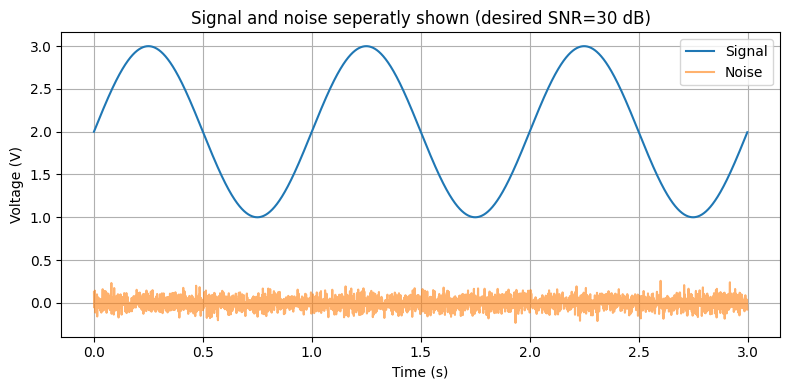

In [36]:
# plot the clean and noisy signals
plt.figure(figsize=(8,4))
plt.plot(t, x_clean, label="Signal")
plt.plot(t, noise, label="Noise", alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Signal and noise seperatly shown (desired SNR={SNRdb} dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

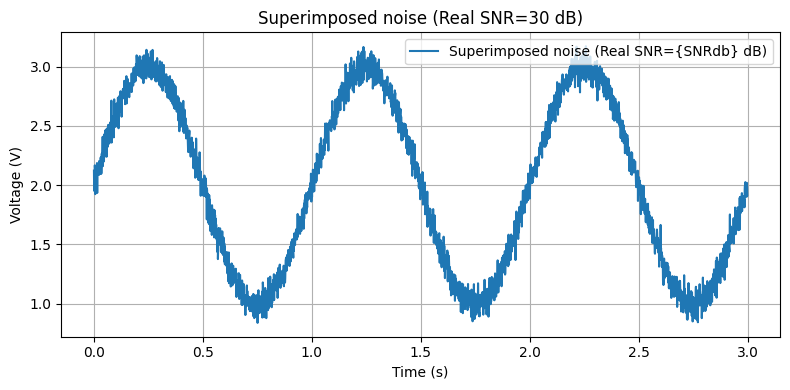

In [37]:
# plot the clean and noisy signals
plt.figure(figsize=(8,4))
plt.plot(t, x_noisy, label="Superimposed noise (Real SNR={SNRdb} dB)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Superimposed noise (Real SNR={SNRdb} dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

/tmp/ipykernel_85154/884789464.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


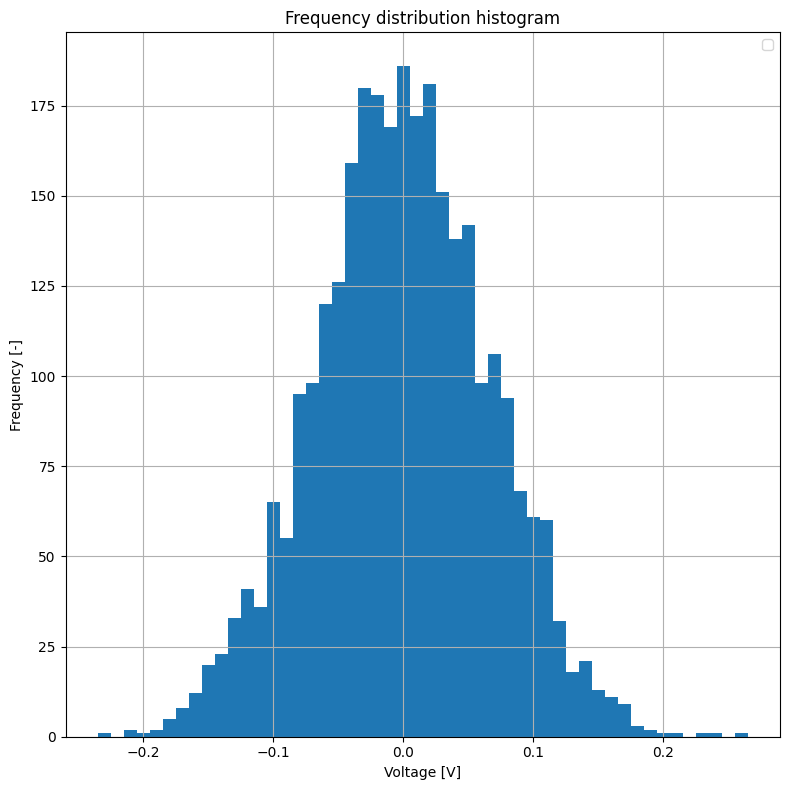

In [38]:
# Frequency distribution histogram with bin width 0.25
plt.figure(figsize=(8,8))
bins = np.arange(np.min(noise), np.max(noise) + 0.01, 0.01)
plt.hist(noise, bins=bins)
plt.xlabel("Voltage [V]")
plt.ylabel("Frequency [-]")
plt.title(f"Frequency distribution histogram")
plt.grid(True)
plt.legend()
plt.tight_layout()


# Conclusion

In conclusion the lab demonstrated how the signal to noise ratio impacts the data. By modelling the noise and clean signal seperatly, we can clearly visualize how the signal will affect the data, and also we are able to (by changing snr) see, if we are still able to identify the signal with the noise applied. I tried testing with different rms values and for example when SNR was 3, you could barely make out what the original signal was. 

We were also able to mathmatically model the gaussian distribuition (bell curve from US textbooks) and also see a small gap between desired and acheived SNR. This is an inherent trait of stochastic processes, because we are sampling in a finite period, there are small discrepencies. IF the data were continous and tended towards infinity, we would see that there would be no discrepency 

